В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

1. Виробництво - для відбраковки деталей на лінії по фото або real-time відео
2. Food apps - для аналізу калорійності їжі по фото
3. В авто для аналізу дорожньої обстановки в real-time по відео

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

1. що кожен layer має однакові нейрони і навчається на певні свої ознаки
2. що функція relu потрібна для того, щоб можна було вивчати нелінійні ознаки
3. pooling потрібен, щоб зберегти найважливіші ознаки, зменшити загальні ваги та запобігти перенавчанню

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [33]:
!pip install --upgrade --force-reinstall numpy

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


In [9]:
!pip install torchmetrics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.8 MB/s eta 0:00:00


In [10]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

# Import matplotlib for visualization
import matplotlib.pyplot as plt

#time measurement
from timeit import default_timer as timer

# Імпортуємо tqdm для індикатора прогресу
from tqdm.auto import tqdm

# Імпорт допоміжних функцій (метрика точності, кроки навчання/тестування, прогнози)
from helper_functions import accuracy_fn, train_step, test_step, print_train_time, make_predictions

import random

#version check
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

import torchmetrics

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

PyTorch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [11]:
# Налаштування коду, незалежного від пристрою
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [12]:
# Training data tuning
train_data = datasets.MNIST(
    root="data", # куди завантажити дані?
    train=True, # отримати навчальні дані
    download=True, # завантажити дані, якщо їх немає на диску
    transform=ToTensor(), # зображення приходять у форматі PIL, ми хочемо перетворити їх на тензори Torch
    target_transform=None # ви також можете перетворити мітки
)

# Налаштування тестових даних
test_data = datasets.MNIST(
    root="data",
    train=False, # отримати тестові дані
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.52MB/s]


In [13]:
# Переглянути класи
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

In [14]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [15]:
len(train_data)

60000

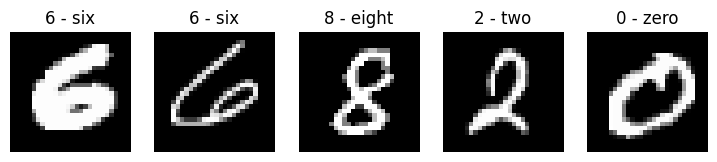

In [16]:
# Відобразити більше зображень
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 1, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [17]:
# Налаштування гіперпараметра розміру партії
BATCH_SIZE = 32

# Перетворення наборів даних на ітерабельні (партії)
train_dataloader = DataLoader(train_data, # набір даних, який потрібно перетворити на ітерабельний
    batch_size=BATCH_SIZE, # скільки зразків на партію?
    shuffle=True # перемішувати дані на кожній епосі?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # не обов'язково перемішувати тестові дані
)

# Давайте перевіримо, що ми створили
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Довжина навчального dataloader: {len(train_dataloader)} партій по {BATCH_SIZE}")
print(f"Довжина тестового dataloader: {len(test_dataloader)} партій по {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e4227ab3d10>, <torch.utils.data.dataloader.DataLoader object at 0x7e42281e1d90>)
Довжина навчального dataloader: 1875 партій по 32
Довжина тестового dataloader: 313 партій по 32


In [18]:
#форма даних
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [19]:
# Створення згорткової нейронної мережі
class FashionMNISTModelV2(nn.Module):
    """
    Архітектура моделі, що копіює TinyVGG з:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # якого розміру квадрат, що проходить по зображенню?
                      stride=1, # за замовчуванням
                      padding=1),# варіанти = "valid" (без заповнення) або "same" (вихід має таку ж форму, як вхід) або int для конкретного числа
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # значення кроку за замовчуванням таке ж, як і розмір ядра
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Звідки взялася ця форма in_features?
            # Це тому, що кожен шар нашої мережі стискає та змінює форму наших вхідних даних.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [20]:
# Налаштування функції втрат та оптимізатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [21]:
device

'cpu'

In [24]:
#навчання на cpu
torch.manual_seed(42)

# Вимірювання часу
train_time_start_model_2 = timer()

# Навчання та тестування моделі
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )




  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33561 | Train accuracy: 88.74%
Test loss: 0.07362 | Test accuracy: 97.71%

Епоха: 1
---------
Train loss: 0.08217 | Train accuracy: 97.44%
Test loss: 0.06596 | Test accuracy: 97.95%

Епоха: 2
---------
Train loss: 0.06436 | Train accuracy: 97.97%
Test loss: 0.05947 | Test accuracy: 98.04%

Епоха: 3
---------
Train loss: 0.05594 | Train accuracy: 98.22%
Test loss: 0.06140 | Test accuracy: 97.92%

Епоха: 4
---------
Train loss: 0.04984 | Train accuracy: 98.42%
Test loss: 0.04684 | Test accuracy: 98.39%



In [25]:
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

Час навчання на cpu: 275.576 секунд


In [16]:
device

'cuda'

In [17]:
#навчання на GPU
torch.manual_seed(42)

# Вимірювання часу
train_time_start_model_2 = timer()

# Навчання та тестування моделі
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33428 | Train accuracy: 88.84%
Test loss: 0.07305 | Test accuracy: 97.76%

Епоха: 1
---------
Train loss: 0.08281 | Train accuracy: 97.45%
Test loss: 0.07517 | Test accuracy: 97.68%

Епоха: 2
---------
Train loss: 0.06484 | Train accuracy: 97.98%
Test loss: 0.05688 | Test accuracy: 98.13%

Епоха: 3
---------
Train loss: 0.05542 | Train accuracy: 98.24%
Test loss: 0.05435 | Test accuracy: 98.02%

Епоха: 4
---------
Train loss: 0.04936 | Train accuracy: 98.45%
Test loss: 0.04485 | Test accuracy: 98.43%



In [18]:
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

Час навчання на cuda: 63.555 секунд


In [26]:
275.576/60

4.592933333333334

Час навчання на CPU склав
при першому запуску 644.592 секунд, тобто до 11 хв
при наступному запуску 275.576 сек, тобто до 5 хв
Час навчання на GPU склав 141.481 секунд, тобто близько 3 хв
На GPU мережа навчалась в 1.5-3 рази швидше

## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [20]:
#вибір тестових зразків
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# Перегляньте форму першого тестового зразка та мітку
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")


Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (2 - two)


In [21]:
# Зробіть прогнози на тестових зразках за допомогою моделі 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# Перегляньте перші два елементи списку ймовірностей прогнозів
pred_probs[:2]

tensor([[1.4565e-12, 1.4103e-08, 1.0000e+00, 1.7198e-09, 1.6171e-17, 1.0130e-16,
         4.8199e-15, 9.1824e-10, 3.4421e-07, 4.7932e-12],
        [2.7293e-07, 9.9842e-01, 1.1319e-05, 8.6604e-07, 6.5842e-06, 1.8383e-04,
         4.7940e-04, 4.6485e-06, 8.1645e-04, 7.7029e-05]])

In [22]:
# Перетворіть ймовірності прогнозів на мітки прогнозів, взявши argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [23]:
#виводимо прогнози та тестові мітки
test_labels, pred_classes

([2, 1, 2, 4, 6, 6, 4, 9, 1], tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]))

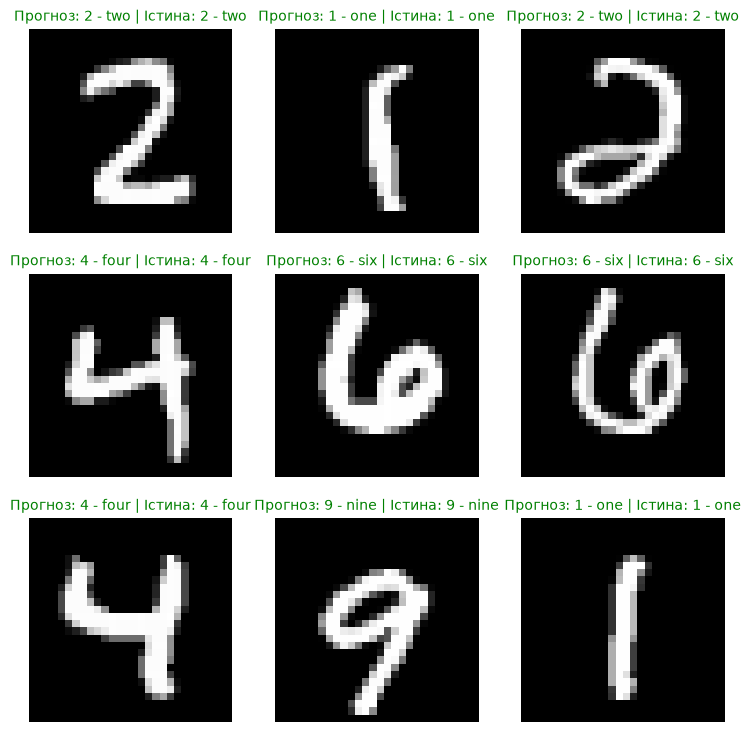

In [24]:
# Побудова прогнозів
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Створити підграфік
  plt.subplot(nrows, ncols, i+1)

  # Побудувати цільове зображення
  plt.imshow(sample.squeeze(), cmap="gray")

  # Знайти мітку прогнозу (в текстовій формі)
  pred_label = class_names[pred_classes[i]]

  # Отримати істинну мітку (в текстовій формі)
  truth_label = class_names[test_labels[i]]

  # Створити текст заголовка графіка
  title_text = f"Прогноз: {pred_label} | Істина: {truth_label}"

  # Перевірити на рівність і змінити колір заголовка відповідно
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # зелений текст, якщо правильно
  else:
      plt.title(title_text, fontsize=10, c="r") # червоний текст, якщо неправильно
  plt.axis(False);

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [25]:
# 1. Зробіть прогнози з навченою моделлю
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Готовність прогнозів"):
    # Відправте дані та цілі на цільовий пристрій
    X, y = X.to(device), y.to(device)
    # Виконайте прямий прохід
    y_logit = model_2(X)
    # Перетворіть прогнози з логітів -> ймовірності прогнозів -> мітки прогнозів
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # зауваження: виконуйте softmax на вимірі "логітів", а не "пакету" (в даному випадку у нас розмір пакету 32, тому можна виконати на dim=1)
    # Помістіть прогнози на CPU для оцінки
    y_preds.append(y_pred.cpu())
# Об'єднайте список прогнозів в тензор
y_pred_tensor = torch.cat(y_preds)

Готовність прогнозів:   0%|          | 0/313 [00:00<?, ?it/s]

In [26]:
# Перевірте, чи існує torchmetrics, якщо ні, встановіть його
try:
    import torchmetrics, mlxtend
    print(f"mlxtend версія: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "версія mlxtend повинна бути 0.19.0 або вище"
except:
    !pip install -q torchmetrics -U mlxtend # <- Примітка: Якщо ви використовуєте Google Colab, це може вимагати перезапуску середовища виконання
    import torchmetrics, mlxtend
    print(f"mlxtend версія: {mlxtend.__version__}")

mlxtend версія: 0.25.0


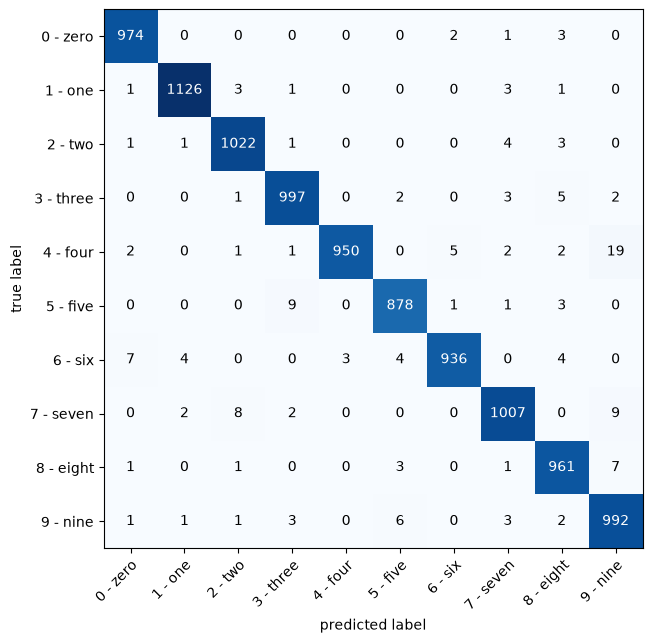

In [28]:
# 2. Налаштування екземпляра матриці плутанини та порівняння прогнозів з цілями
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib любить працювати з NumPy
    class_names=class_names, # перетворення міток рядків і стовпців на назви класів
    figsize=(10, 7)
);

По confusion matrix видно, що модель працює досить добре.
Найбільша кількість помилок у випадках, коли модель прийняла 4 за 9, 5 за 3, 7 за 2.

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [29]:
errors_indexes = (y_pred_tensor != test_data.targets).nonzero().squeeze().tolist()

print(f"Кількість помилок: {len(errors_indexes)} з {len(test_data)}")

Кількість помилок: 157 з 10000


In [30]:
random.seed(42)
errors_sample_indexes = random.sample(errors_indexes, k=9)
error_samples = []
error_labels = []
error_preds = []

for idx in errors_sample_indexes:
  sample, label = test_data[idx]
  error_samples.append(sample)
  error_labels.append(label)
  error_preds.append(y_pred_tensor[idx].item())

# Перегляньте форму першого тестового зразка та мітку
print(f"Test sample image shape: {error_samples[0].shape}\nTest sample label: {error_labels[0]} ({class_names[error_labels[0]]})")


Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 6 (6 - six)


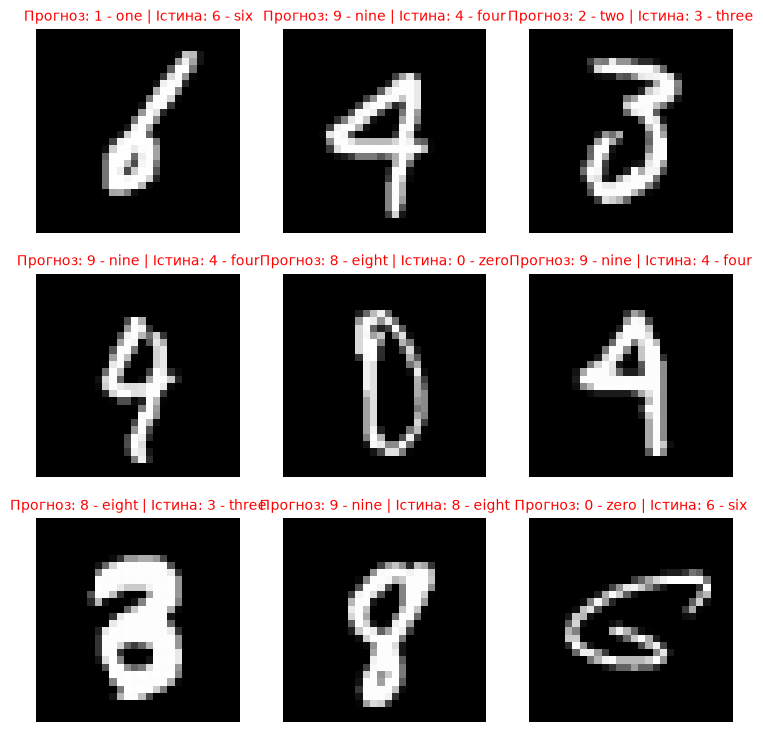

In [32]:
#Виведення помилок моделі

# Побудова прогнозів
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(error_samples):
  # Створити підграфік
  plt.subplot(nrows, ncols, i+1)

  # Побудувати цільове зображення
  plt.imshow(sample.squeeze(), cmap="gray")

  # Знайти мітку прогнозу (в текстовій формі)
  pred_label = class_names[error_preds[i]]

  # Отримати істинну мітку (в текстовій формі)
  truth_label = class_names[error_labels[i]]

  # Створити текст заголовка графіка
  title_text = f"Прогноз: {pred_label} | Істина: {truth_label}"


  plt.title(title_text, fontsize=10, c="r") # червоний текст, якщо неправильно
  plt.axis(False);

Після візуалізації кількох прикладів, мені схоже на те, що мітки в даних правильні і це все ж помилка моделі. Дані справді складні, але для людського око ще розбірливі

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [43]:
#створюю випадковий тензор форми [1, 3, 64, 64]
images = torch.randn(size=(1, 3, 64, 64))
test_image = images[0]
print(f"Форма пакету зображень: {images.shape} -> [розмір_пакету, кольорові_канали, висота, ширина]")
print(f"Форма одного зображення: {test_image.shape} -> [кольорові_канали, висота, ширина]")
print(f"Піксельні значення одного зображення:\n{test_image}")

Форма пакету зображень: torch.Size([1, 3, 64, 64]) -> [розмір_пакету, кольорові_канали, висота, ширина]
Форма одного зображення: torch.Size([3, 64, 64]) -> [кольорові_канали, висота, ширина]
Піксельні значення одного зображення:
tensor([[[ 0.8637, -0.5890, -1.0340,  ...,  0.3088,  1.6617,  0.1751],
         [ 0.3273,  0.1292,  2.8520,  ...,  0.3715,  0.2697,  0.7900],
         [-0.2130, -0.5904,  0.4668,  ..., -0.6126, -0.4835, -0.5419],
         ...,
         [ 0.3930,  0.2149, -2.5638,  ...,  0.2031, -0.7018,  0.4985],
         [ 0.3414,  0.4126, -2.7346,  ...,  0.6016,  0.6290, -0.3941],
         [-0.3181, -1.7160,  0.3757,  ..., -0.4996,  1.1848, -1.1461]],

        [[-0.5077,  0.4996, -0.7233,  ...,  0.4829, -0.1637, -0.8903],
         [ 0.2514,  0.5850,  1.0414,  ...,  0.3212, -1.4201,  0.7609],
         [-0.8508,  0.1698,  0.3122,  ..., -0.4985, -0.5410,  0.6816],
         ...,
         [ 1.2646, -0.0746, -0.6203,  ...,  0.9925, -0.8622,  0.7690],
         [ 0.6962, -0.1167,  0.

In [44]:
#створюю шар nn.Conv2d(), kernel = 3x3
torch.manual_seed(42)

# Створіть згортковий шар з такими ж розмірами, як у TinyVGG
# (спробуйте змінити будь-який з параметрів і подивіться, що станеться)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # також спробуйте використати "valid" або "same" тут
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [46]:
#створюю шар nn.Conv2d(), kernel=7x7
torch.manual_seed(42)

# Створіть згортковий шар з такими ж розмірами, як у TinyVGG
# (спробуйте змінити будь-який з параметрів і подивіться, що станеться)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=7,
                       stride=1,
                       padding=0) # також спробуйте використати "valid" або "same" тут
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 58, 58])

In [54]:
#створюю шар nn.Conv2d(), experiments
torch.manual_seed(42)

# Створіть згортковий шар з такими ж розмірами, як у TinyVGG
# (спробуйте змінити будь-який з параметрів і подивіться, що станеться)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # також спробуйте використати "valid" або "same" тут
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

При збільшенні розміру kernel, розмір зображення на виході шару зменшується і навпаки
При збільшенні stride, розмір зображення на виході шару суттєво зменшується, але частина даних просто пропускається при навчанні
При зміні padding на 1 або 'same' то розмір зображення буде однаковим на виході і на вході; 0 і 'valid' - трохи його зменшують
